In [1]:
import sys
import os
import yaml
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.stats import norm

In [7]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(device)

cuda


In [8]:
def noisy_function(x):
    """Example noisy function to optimize: f(x) = (x - 3)^2 + noise"""
    noise = torch.randn_like(x) * 0.01  # Adding Gaussian noise
    return (x - 3) ** 2 + noise


In [9]:
def kiefer_wolfowitz_optimization(lr=0.01, perturbation=0.05, iterations=500000):
    """Kiefer-Wolfowitz optimization in PyTorch."""
    x = torch.tensor([0.0], requires_grad=False)  # Initial guess
    xsave = []
    for i in range(iterations):
        c_n = perturbation / (i + 1) ** 0.5  # Decaying perturbation
        a_n = lr / (i + 1) ** 0.6  # Decaying step size
        
        # Evaluate function at perturbed points
        f_plus = noisy_function(x + c_n)
        f_minus = noisy_function(x - c_n)
        
        # Approximate gradient
        gradient_estimate = (f_plus - f_minus) / (2 * c_n)
        
        # Update step
        x -= a_n * gradient_estimate
        xsave.append(x.item())
        # Logging
        if i % 10 == 0:
            print(f"Iteration {i}: x = {x.item():.4f}")
    
    return x, xsave

In [10]:
# Run the optimization
optimal_x, xsave = kiefer_wolfowitz_optimization()
print(f"Estimated optimal x: {optimal_x.item():.4f}")

Iteration 0: x = 0.0601
Iteration 10: x = 0.2700
Iteration 20: x = 0.3698
Iteration 30: x = 0.4450
Iteration 40: x = 0.5036
Iteration 50: x = 0.5535
Iteration 60: x = 0.5977
Iteration 70: x = 0.6347
Iteration 80: x = 0.6710
Iteration 90: x = 0.7011
Iteration 100: x = 0.7282
Iteration 110: x = 0.7526
Iteration 120: x = 0.7810
Iteration 130: x = 0.8090
Iteration 140: x = 0.8283
Iteration 150: x = 0.8480
Iteration 160: x = 0.8677
Iteration 170: x = 0.8882
Iteration 180: x = 0.9070
Iteration 190: x = 0.9258
Iteration 200: x = 0.9389
Iteration 210: x = 0.9535
Iteration 220: x = 0.9677
Iteration 230: x = 0.9841
Iteration 240: x = 1.0028
Iteration 250: x = 1.0176
Iteration 260: x = 1.0351
Iteration 270: x = 1.0469
Iteration 280: x = 1.0630
Iteration 290: x = 1.0745
Iteration 300: x = 1.0861
Iteration 310: x = 1.1042
Iteration 320: x = 1.1168
Iteration 330: x = 1.1252
Iteration 340: x = 1.1345
Iteration 350: x = 1.1480
Iteration 360: x = 1.1597
Iteration 370: x = 1.1664
Iteration 380: x = 1.17

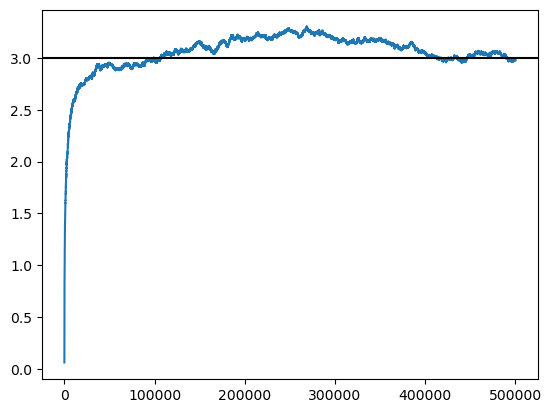

In [11]:
plt.plot(xsave)
plt.axhline(y=3., color='k', linestyle='-')
plt.show()

In [16]:
import torch
import numpy as np

class KieferWolfowitzRegression:
    def __init__(self, n_features, lr=0.001, perturbation=0.05, iterations=500000, batch_size=32):
        self.lr = lr
        self.perturbation = perturbation
        self.iterations = iterations
        self.batch_size = batch_size
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.w = torch.zeros(n_features, device=self.device, requires_grad=False)  # Initialize weights

    def noisy_function(self, w, X, y):
        """Noisy loss function for linear regression: MSE with noise"""
        noise = torch.randn(1, device=self.device) * 0.1  # Adding Gaussian noise
        predictions = X @ w
        return ((predictions - y) ** 2).mean() + noise.item()

    def fit(self, X, y):
        X, y = X.to(self.device), y.to(self.device)  # Move data to the device
        wsave = []
        n_samples, n_features = X.shape
        
        for i in range(self.iterations):
            # Sample a batch
            indices = torch.randint(0, n_samples, (self.batch_size,), device=self.device)
            X_batch = X[indices]
            y_batch = y[indices]
            
            c_n = self.perturbation / (i + 1) ** 0.5  # Decaying perturbation
            a_n = self.lr / (i + 1) ** 0.5  # Adjusted decay rate for step size
            
            gradient_estimate = torch.zeros_like(self.w)
            for j in range(len(self.w)):
                perturb = torch.zeros_like(self.w)
                perturb[j] = c_n
                f_plus = self.noisy_function(self.w + perturb, X_batch, y_batch)
                f_minus = self.noisy_function(self.w - perturb, X_batch, y_batch)
                gradient_estimate[j] = (f_plus - f_minus) / (2 * c_n)
            
            # Update step
            self.w -= a_n * gradient_estimate
            wsave.append(self.w.cpu().numpy().copy())  # Make sure to append a copy of the current weights
            
            # Logging
            if i % 1000 == 0:  # Log every 1000 iterations to reduce output
                print(f"Iteration {i}: w = {self.w.cpu().numpy()}")
        
        return self.w, np.array(wsave)

    def predict(self, X):
        X = X.to(self.device)
        return X @ self.w

# Example usage:
if __name__ == "__main__":
    # Generate synthetic data
    torch.manual_seed(42)
    n_samples, n_features = 100, 5  # Updated to 5 features for scalability demonstration
    X = torch.randn((n_samples, n_features))  # Deterministic coordinates
    true_w = torch.tensor([2.0, -3.0, 1.0, 0.5, -1.5])  # Updated to match n_features
    y = X @ true_w + torch.randn(n_samples) * 0.1  # Adding noise

    # Initialize and run the optimization
    model = KieferWolfowitzRegression(n_features=n_features)
    estimated_w, wsave = model.fit(X, y)
    print(f"Estimated weights: {estimated_w.cpu().numpy()}")

Iteration 0: w = [ 0.00412562 -0.00537496 -0.00190311  0.00080812 -0.00328956]
Iteration 1000: w = [ 0.18405887 -0.2902363   0.05412088  0.05066043 -0.08361527]
Iteration 2000: w = [ 0.24832813 -0.44265714  0.10958385  0.10550945 -0.12869294]
Iteration 3000: w = [ 0.27004176 -0.5457042   0.20029426  0.18310383 -0.14145334]
Iteration 4000: w = [ 0.29288724 -0.61683816  0.31173024  0.22666101 -0.02321102]
Iteration 5000: w = [ 0.34967917 -0.55550814  0.3265338   0.22783671 -0.05418032]
Iteration 6000: w = [ 0.39768565 -0.5856865   0.3318887   0.2582371  -0.06194904]
Iteration 7000: w = [ 0.39860672 -0.576892    0.35878292  0.27026996 -0.11741021]
Iteration 8000: w = [ 0.45684808 -0.6733444   0.39235926  0.28092423 -0.27326694]
Iteration 9000: w = [ 0.47042307 -0.65328485  0.39380223  0.26300028 -0.34974712]
Iteration 10000: w = [ 0.3352623  -0.73874384  0.38823965  0.31589288 -0.42854947]
Iteration 11000: w = [ 0.27296922 -0.76429623  0.3721436   0.3466998  -0.43611503]
Iteration 12000: 

[[ 3.4969712e-03 -5.6295302e-03  4.5505527e-04  1.0395814e-03
  -5.4044630e-03]
 [ 5.3017428e-03 -1.2663336e-02  2.7923393e-03  2.2271536e-03
  -5.8077336e-03]
 [ 8.1169512e-03 -1.7022017e-02  4.5015141e-03  2.1790694e-03
  -7.8448011e-03]
 ...
 [ 1.4426522e+00 -2.8931715e+00  6.8015444e-01  9.8269159e-01
  -1.0504750e+00]
 [ 1.4442656e+00 -2.8919721e+00  6.7948270e-01  9.8371994e-01
  -1.0511721e+00]
 [ 1.4443359e+00 -2.8913014e+00  6.8255353e-01  9.8181450e-01
  -1.0535468e+00]]


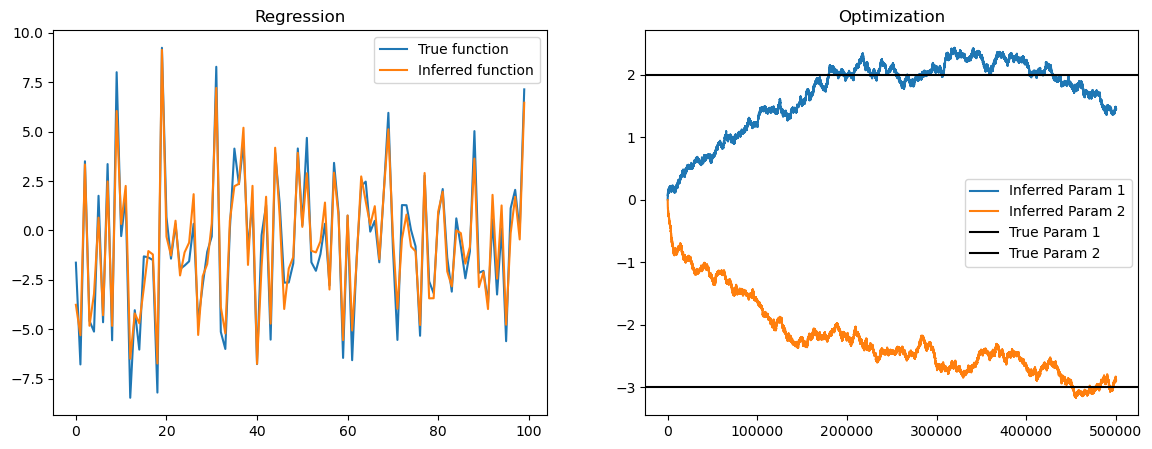

In [13]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(y, label = 'True function')
plt.plot((X @ estimated_w + torch.randn(n_samples) * 0.1).numpy(), label = 'Inferred function')
plt.title('Regression')
plt.legend()

# Plot solution u(x)
plt.subplot(1, 2, 2)
print(wsave)
plt.plot(wsave[:, 0], label='Inferred Param 1')
plt.plot(wsave[:, 1], label='Inferred Param 2')
plt.axhline(2, color = 'k', label = 'True Param 1')
plt.axhline(-3, color = 'k', label = 'True Param 2')
plt.title('Optimization')
plt.legend()

# plt.tight_layout()
plt.show()

In [1]:
import torch
from torch.optim.optimizer import Optimizer, required

class KieferWolfowitzOptimizer(Optimizer):
    def __init__(self, params, lr=required, perturbation=0.05):
        if lr is not required and lr < 0.0:
            raise ValueError("Invalid learning rate: {}".format(lr))
        if perturbation < 0.0:
            raise ValueError("Invalid perturbation: {}".format(perturbation))
        
        defaults = dict(lr=lr, perturbation=perturbation)
        super(KieferWolfowitzOptimizer, self).__init__(params, defaults)

    def step(self, closure=None):
        """Performs a single optimization step."""
        loss = None
        if closure is not None:
            loss = closure()

        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None:
                    continue

                lr = group['lr']
                perturbation = group['perturbation']

                state = self.state[p]

                # State initialization
                if len(state) == 0:
                    state['iteration'] = 0
                    state['gradient_estimate'] = torch.zeros_like(p.data)

                iteration = state['iteration']
                gradient_estimate = state['gradient_estimate']

                c_n = perturbation / (iteration + 1) ** 0.5  # Decaying perturbation
                a_n = lr / (iteration + 1) ** 0.5  # Adjusted decay rate for step size

                perturb = torch.zeros_like(p.data)
                f_plus_list = []
                f_minus_list = []
                original_data = p.data.clone()
                for j in range(p.data.numel()):
                    perturb.view(-1)[j] = c_n
                    p.data.add_(perturb)
                    f_plus = closure()  # Function value at (w + perturb)
                    f_plus_list.append(f_plus.item())
                    p.data.copy_(original_data)
                    
                    perturb.view(-1)[j] = -c_n
                    p.data.add_(perturb)
                    f_minus = closure()  # Function value at (w - perturb)
                    f_minus_list.append(f_minus.item())
                    p.data.copy_(original_data)
                    
                    perturb.view(-1)[j] = 0

                f_plus = torch.tensor(f_plus_list, device=p.device)
                f_minus = torch.tensor(f_minus_list, device=p.device)

                for j in range(p.data.numel()):
                    gradient_estimate.view(-1)[j] = (f_plus[j] - f_minus[j]) / (2 * c_n)

                p.data -= a_n * gradient_estimate

                state['iteration'] += 1

        return loss

# Example usage:
if __name__ == "__main__":
    # Generate synthetic data
    torch.manual_seed(42)
    n_samples, n_features = 100, 5  # Updated to 5 features for scalability demonstration
    X = torch.randn((n_samples, n_features))  # Deterministic coordinates
    true_w = torch.tensor([2.0, -3.0, 1.0, 0.5, -1.5], dtype=torch.float32)  # Updated to match n_features
    y = X @ true_w + torch.randn(n_samples) * 0.1  # Adding noise

    # Define a simple linear regression model
    model = torch.nn.Linear(n_features, 1, bias=False)
    criterion = torch.nn.MSELoss()

    # Move model and data to GPU if available
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    X, y = X.to(device), y.to(device).view(-1, 1)

    # Initialize the optimizer
    optimizer = KieferWolfowitzOptimizer(model.parameters(), lr=0.01, perturbation=0.05)

    # Training loop
    num_epochs = 10000
    for epoch in range(num_epochs):
        def closure():
            optimizer.zero_grad()
            outputs = model(X)
            loss = criterion(outputs, y)
            loss.backward()
            return loss

        loss = optimizer.step(closure)

        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item()}")

    # Print the estimated weights
    estimated_w = model.weight.data.cpu().numpy()
    print(f"Estimated weights: {estimated_w}")

Epoch 0, Loss: 14.47814655303955
Epoch 100, Loss: 7.75775671005249
Epoch 200, Loss: 5.91044282913208
Epoch 300, Loss: 4.804808139801025
Epoch 400, Loss: 4.03901481628418
Epoch 500, Loss: 3.4685075283050537
Epoch 600, Loss: 3.023963451385498
Epoch 700, Loss: 2.6667070388793945
Epoch 800, Loss: 2.372993230819702
Epoch 900, Loss: 2.127248764038086
Epoch 1000, Loss: 1.9187380075454712
Epoch 1100, Loss: 1.739772915840149
Epoch 1200, Loss: 1.5846848487854004
Epoch 1300, Loss: 1.449181318283081
Epoch 1400, Loss: 1.3299522399902344
Epoch 1500, Loss: 1.2243883609771729
Epoch 1600, Loss: 1.130413293838501
Epoch 1700, Loss: 1.0463504791259766
Epoch 1800, Loss: 0.9708248972892761
Epoch 1900, Loss: 0.9027021527290344
Epoch 2000, Loss: 0.8410370945930481
Epoch 2100, Loss: 0.7850355505943298
Epoch 2200, Loss: 0.734024703502655
Epoch 2300, Loss: 0.6874330639839172
Epoch 2400, Loss: 0.6447676420211792
Epoch 2500, Loss: 0.6056077480316162
Epoch 2600, Loss: 0.5695835947990417
Epoch 2700, Loss: 0.53637540

In [3]:
import torch
from torch.optim.optimizer import Optimizer, required

class KieferWolfowitzOptimizer(Optimizer):
    def __init__(self, params, lr=required, perturbation=0.05):
        if lr is not required and lr < 0.0:
            raise ValueError("Invalid learning rate: {}".format(lr))
        if perturbation < 0.0:
            raise ValueError("Invalid perturbation: {}".format(perturbation))
        
        defaults = dict(lr=lr, perturbation=perturbation)
        super(KieferWolfowitzOptimizer, self).__init__(params, defaults)

    def step(self, closure=None):
        """Performs a single optimization step."""
        loss = None
        if closure is not None:
            loss = closure()

        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None:
                    continue

                lr = group['lr']
                perturbation = group['perturbation']

                state = self.state[p]

                # State initialization
                if len(state) == 0:
                    state['iteration'] = 0
                    state['gradient_estimate'] = torch.zeros_like(p.data)

                iteration = state['iteration']
                gradient_estimate = state['gradient_estimate']

                c_n = perturbation / (iteration + 1) ** 0.5  # Decaying perturbation
                a_n = lr / (iteration + 1) ** 0.5  # Adjusted decay rate for step size

                original_data = p.data.clone()
                perturb = torch.zeros_like(p.data)

                # Batch processing for f_plus and f_minus
                perturbations = torch.eye(p.data.numel(), device=p.device) * c_n
                perturbations = perturbations.view(-1, *p.data.shape)

                f_plus_list = []
                f_minus_list = []

                for perturbation in perturbations:
                    p.data.copy_(original_data + perturbation)
                    f_plus = closure()
                    f_plus_list.append(f_plus.item())
                
                for perturbation in perturbations:
                    p.data.copy_(original_data - perturbation)
                    f_minus = closure()
                    f_minus_list.append(f_minus.item())

                f_plus = torch.tensor(f_plus_list, device=p.device)
                f_minus = torch.tensor(f_minus_list, device=p.device)

                gradient_estimate = (f_plus - f_minus) / (2 * c_n)
                gradient_estimate = gradient_estimate.view_as(p.data)

                p.data.copy_(original_data - a_n * gradient_estimate)

                state['iteration'] += 1

        return loss

if __name__ == "__main__":
    # Generate synthetic data
    torch.manual_seed(42)
    n_samples, n_features = 1000, 5  # Updated to 5 features for scalability demonstration
    X = torch.randn((n_samples, n_features))  # Deterministic coordinates
    true_w = torch.tensor([2.0, -3.0, 1.0, 0.5, -1.5], dtype=torch.float32)  # Updated to match n_features
    y = X @ true_w + torch.randn(n_samples) * 0.1  # Adding noise

    # Define a simple linear regression model
    model = torch.nn.Linear(n_features, 1, bias=False)
    criterion = torch.nn.MSELoss()

    # Move model and data to GPU if available
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    X, y = X.to(device), y.to(device).view(-1, 1)

    # Initialize the optimizer
    optimizer = KieferWolfowitzOptimizer(model.parameters(), lr=0.01, perturbation=0.05)

    # Training loop with batching
    num_epochs = 1000
    batch_size = 100
    num_batches = n_samples // batch_size

    for epoch in range(num_epochs):
        permutation = torch.randperm(n_samples)
        
        for i in range(0, n_samples, batch_size):
            indices = permutation[i:i + batch_size]
            batch_X, batch_y = X[indices], y[indices]

            def closure():
                optimizer.zero_grad()
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                loss.backward()
                return loss

            loss = optimizer.step(closure)

        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item()}")

    # Print the estimated weights
    estimated_w = model.weight.data.cpu().numpy()
    print(f"Estimated weights: {estimated_w}")

Epoch 0, Loss: 17.965484619140625
Epoch 100, Loss: 2.3386638164520264
Epoch 200, Loss: 1.075921654701233
Epoch 300, Loss: 0.24365802109241486
Epoch 400, Loss: 0.19087503850460052
Epoch 500, Loss: 0.05332031473517418
Epoch 600, Loss: 0.10584785789251328
Epoch 700, Loss: 0.09578652679920197
Epoch 800, Loss: 0.013903262093663216
Epoch 900, Loss: 0.04058624804019928
Epoch 1000, Loss: 0.03995904326438904
Epoch 1100, Loss: 0.017622647807002068
Epoch 1200, Loss: 0.013034313917160034
Epoch 1300, Loss: 0.00618823803961277
Epoch 1400, Loss: 0.039577435702085495
Epoch 1500, Loss: 0.02777172438800335
Epoch 1600, Loss: 0.006796668749302626
Epoch 1700, Loss: 0.012519866228103638
Epoch 1800, Loss: 0.010239056311547756
Epoch 1900, Loss: 0.016529137268662453
Epoch 2000, Loss: 0.026076961308717728
Epoch 2100, Loss: 0.008057760074734688
Epoch 2200, Loss: 0.017749469727277756
Epoch 2300, Loss: 0.017310699447989464
Epoch 2400, Loss: 0.009891510009765625
Epoch 2500, Loss: 0.009230745024979115
Epoch 2600, Lo